# ETA $\Large\eta$

In [362]:
import pandas as pd
import numpy as np

In [363]:
import seaborn as sns
import matplotlib.pyplot as plt
import plotly_express as px
import altair as alt

# Define Library

In [364]:
lib = {
    'koran': (['chap_num', 'verse_num', 'token_num'], "./koran-TOKEN.csv", 1),
    'ajtzibab': (['para_id', 'line_id', 'token_num'], "../../notebooks/ajtzibab/ajtzibab-TOKEN.csv", 1),
    'christenson': (['chap_num', 'line_num', 'token_num'], "../../notebooks/christenson/christenson-TOKEN_QUC.csv", 1),
    'colop': (['parte', 'capit', 'token_num'], "../../notebooks/colop/colop-TOKEN.csv", 2),
    'christenson-quiche': (['para_num', 'sent_num', 'token_num'], "../../notebooks/ximenez-christenson/christenson-quiche-TOKEN.csv", 1)
}

In [365]:
LIB = pd.DataFrame(lib).T
LIB.columns = ['ohco', 'src_file', 'doc_ohco_level']
LIB.index.name = 'corpus_id'

In [366]:
LIB

,ohco,src_file,doc_ohco_level
corpus_id,,,
koran,"[chap_num, verse_num, token_num]",./koran-TOKEN.csv,1
ajtzibab,"[para_id, line_id, token_num]",../../notebooks/ajtzibab/ajtzibab-TOKEN.csv,1
christenson,"[chap_num, line_num, token_num]",../../notebooks/christenson/christenson-TOKEN_...,1
colop,"[parte, capit, token_num]",../../notebooks/colop/colop-TOKEN.csv,2
christenson-quiche,"[para_num, sent_num, token_num]",../../notebooks/ximenez-christenson/christenso...,1


In [367]:
def get_token_df(slug):
    # ohco = lib[slug][0]
    ohco = LIB.loc[slug, 'ohco']
    return pd.read_csv(lib[slug][1]).set_index(ohco)[['token_str', 'term_str']]

# Check out text

In [368]:
slug = 'christenson'
# slug = 'ajtzibab'
# slug = 'colop'
# slug = 'christenson-quiche'
TOKEN = get_token_df(slug)

# Create Corpus

In [369]:
import importlib
import eta as ŋ
importlib.reload(ŋ)

ŋ.export_dir = "./export"

corpus = ŋ.Corpus(TOKEN, list(TOKEN.index.names), slug=slug)
corpus.extract_vocab()
for c in [40, 50, 60, 80, 100]:
    corpus.add_chunk_col(c)
corpus.export_data()

In [370]:
# chap.DOC_IDX

# Create chap and chunk Docs

In [371]:
ohco_offset = LIB.loc[slug, 'doc_ohco_level']
doc_cols = LIB.loc[slug, 'ohco'][:ohco_offset]

In [372]:
doc_cols

['chap_num']

In [373]:
# chap = ŋ.Doc(corpus, group_cols=doc_cols, doc_name='chap')
# chap.make_bow_df()
# chap.make_count_matrix()
# chap.compute_term_significance()
# chap.define_sig_terms(agg_func='median')
# chap.make_tfidf_df()
# chap.compute_pca()
# chap.export_data()

In [374]:
c_num = 80
chunk = ŋ.Doc(corpus, group_cols=[f'chunk_{c_num}_id'], doc_name='chunk60')
chunk.make_bow_df()
chunk.make_count_matrix()
chunk.compute_term_significance()
chunk.define_sig_terms(agg_func='mean')
chunk.make_tfidf_df()
chunk.compute_pca()
chunk.export_data()

# Cluster Docs

### By Chap

In [375]:
# chap_cluster = ŋ.Cluster(chap)
# chap_cluster.metric = 'euclidean'
# chap_cluster.make_tfidf_dist_df()

In [376]:
# sns.clustermap(chap_cluster.X, col_cluster=False, cmap="YlGnBu_r");

In [377]:
# chap_cluster.cluster_tfidf()
# chap_cluster.show_tree(.22)

In [378]:
# chap_cluster.get_clusters()
# chap_cluster.assign_cluster_tfidf_values()
# chap_cluster.create_cluster_model()

In [379]:
# px.imshow(chap_cluster.CLUSTER_MODEL,
#          color_continuous_scale=px.colors.carto.Aggrnyl, 
#          title=f"{chap_cluster.doc.corpus.slug.capitalize()} {chap_cluster.doc.doc_name.upper()} clusters with Δ = {chap_cluster.tfidf_hac.color_thresh}")

In [380]:
# chap_cluster.export_data()

### By Chunk

In [381]:
chunk_cluster = ŋ.Cluster(chunk)
chunk_cluster.make_tfidf_dist_df()
# chunk_cluster.metric = 'cosine'

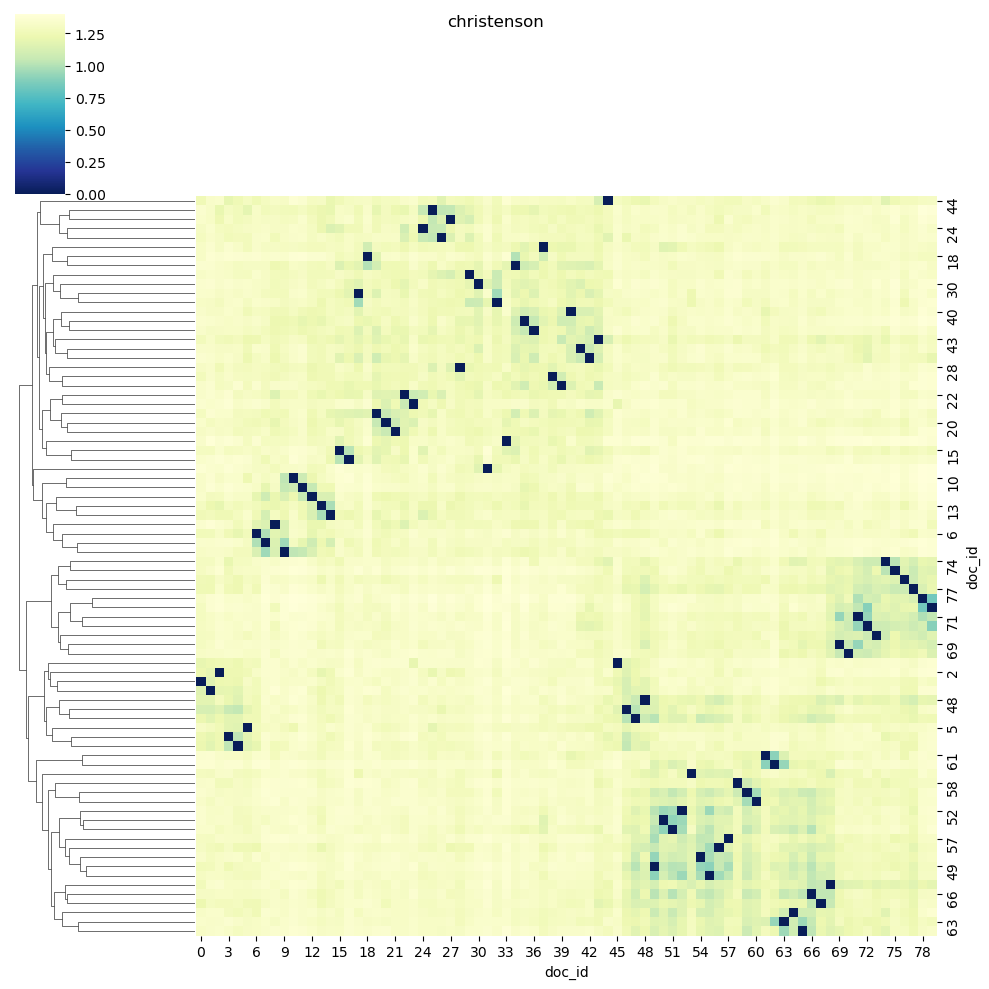

In [382]:
sns.clustermap(chunk_cluster.X, 
               metric='euclidean', 
               method='average', 
               col_cluster=False, 
               cmap="YlGnBu_r").fig.suptitle(slug);

In [383]:
# chunk_cluster.cluster_tfidf_dist()
# chunk_cluster.tfidf_dist_hac.color_thresh = .23
# chunk_cluster.tfidf_dist_hac.plot_tree()

<Figure size 640x480 with 0 Axes>

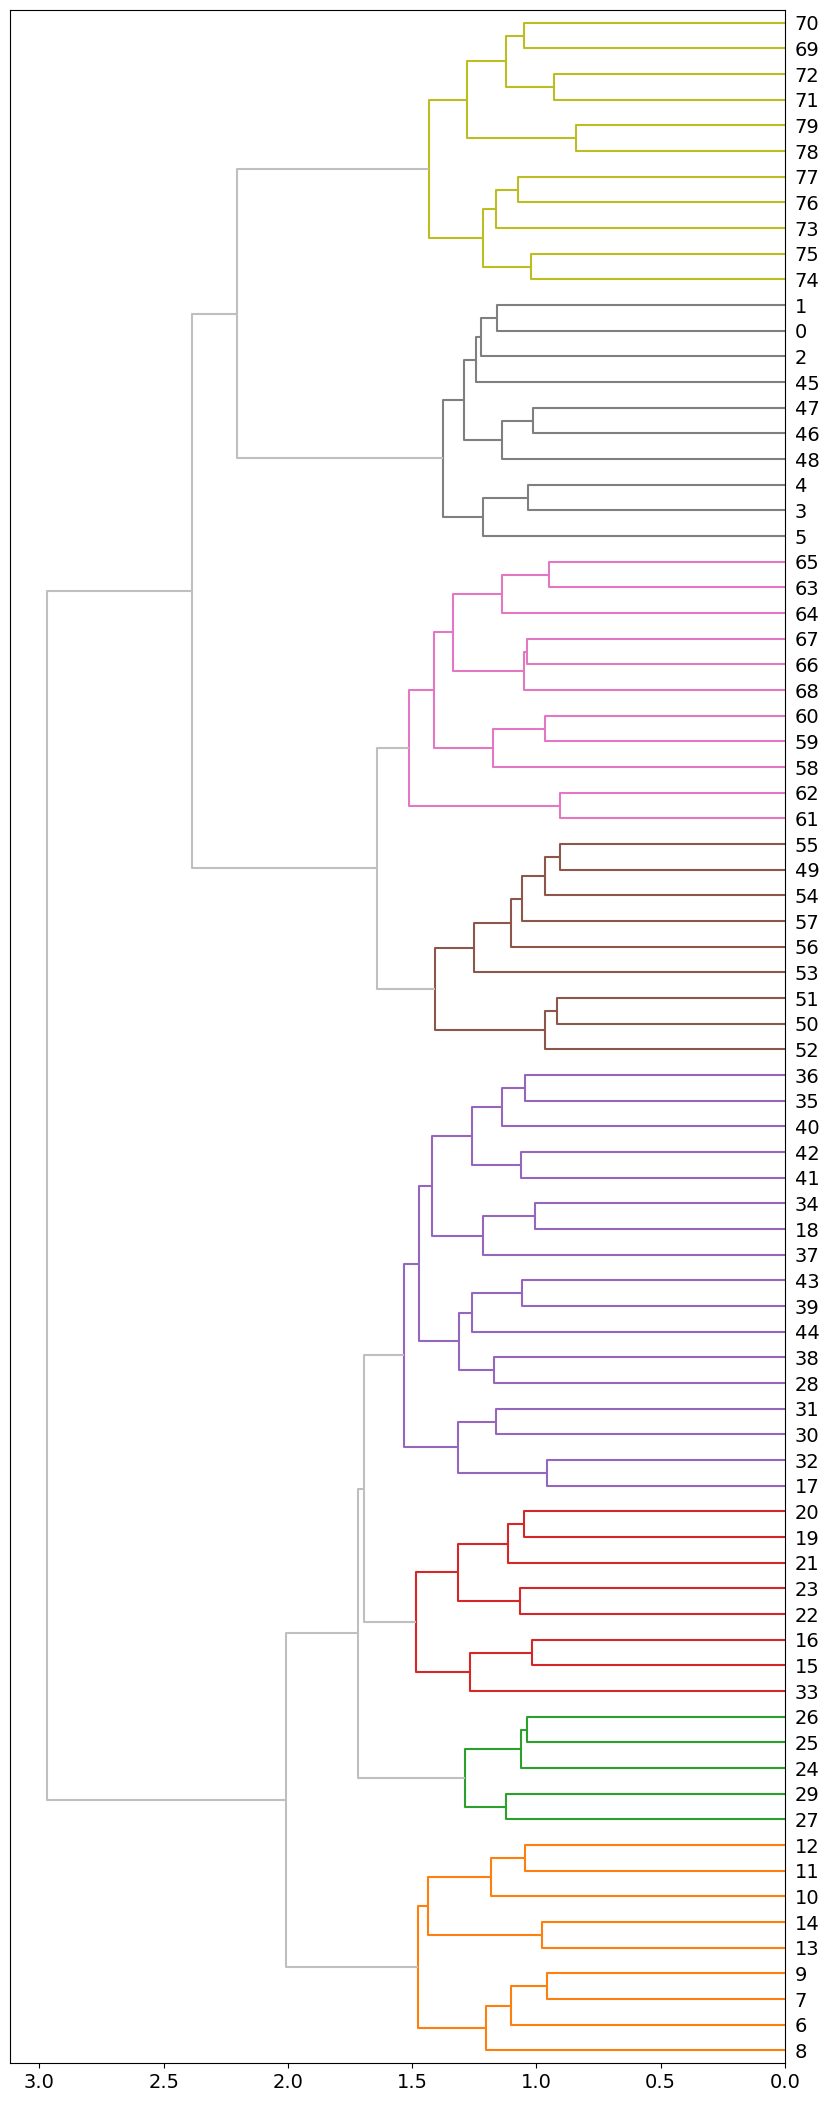

In [504]:
chunk_cluster.cluster_tfidf()
chunk_cluster.tfidf_hac.color_thresh = 1.6
# chunk_cluster.show_tree(1.5)
chunk_cluster.show_tree()

In [505]:
# chunk_cluster.tfidf_hac.dendro

In [506]:
chunk_cluster.get_clusters()
chunk_cluster.assign_cluster_tfidf_values()
chunk_cluster.create_cluster_model()

In [507]:
chunk_cluster.CLUSTER.top_terms

cluster_letter
A                kaj, b'it, winaq, tz'aq, aj, ulew, qa
B    kaqix, sipakna, k'ajolab', wuqub', kab'raqan, ...
C        q'apoj, xcha', jun, kame, junajpu, ajal, kik'
D         xib'alb'a, kame, xecha', b'a, k'ate, pa, jun
E        kati't, qati't, jun, chowen, ix, b'atz', che'
F    b'alam, tojil, k'ab'awil, kitze, q'ij, b'i', q...
G        b'alam, amaq', e, tojil, q'apojib', aj, kitze
H             ajaw, ja, ajawab', tinamit, aj, pop, nim
Name: top_terms, dtype: object

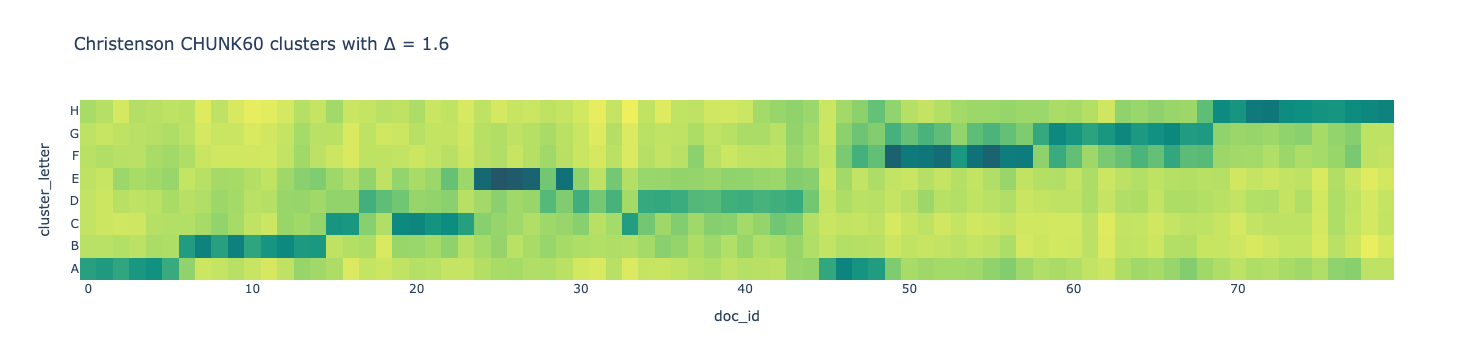

In [508]:
px.imshow(
    chunk_cluster.CLUSTER_MODEL.T.sort_index(ascending=False),
    color_continuous_scale=px.colors.carto.Aggrnyl, 
    title=f"{chunk_cluster.doc.corpus.slug.capitalize()} {chunk_cluster.doc.doc_name.upper()} clusters with Δ = {chunk_cluster.tfidf_hac.color_thresh}"
).update_layout(coloraxis_showscale=False)

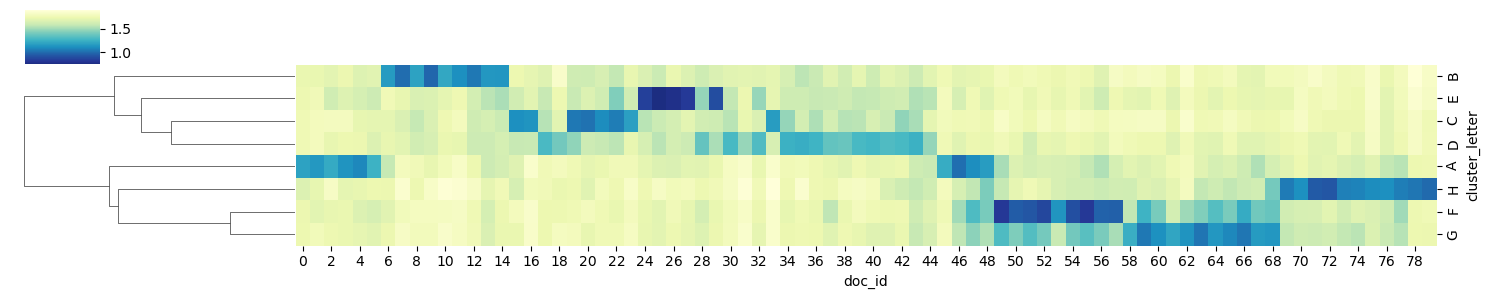

In [557]:
color_center = chunk_cluster.CLUSTER_MODEL.mean().mean()
sns.clustermap(chunk_cluster.CLUSTER_MODEL.T**2, metric='correlation', col_cluster=False, cmap='YlGnBu_r', center=color_center, figsize=(15,3));

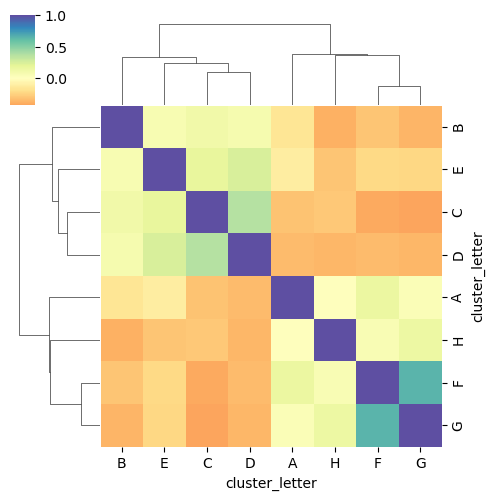

In [555]:
sns.clustermap(chunk_cluster.CLUSTER_MODEL.corr(), cmap='Spectral', center=0, figsize=(5,5));

In [389]:
chunk_cluster.export_data()

# Topic Models

## Chap Model

In [390]:
# chap_model = ŋ.Model(chap)
# # chap_model.alter_k(chap_cluster.k)
# chap_model.alter_k(6)
# chap_model.alpha_W = .1
# chap_model.alpha_H = 0
# chap_model.l1_ratio = 0
# chap_model.compute_topics()

In [391]:
# chap_model.TOPIC.top_terms

In [392]:
# px.imshow(chap_model.THETA.T.sort_index(ascending=False), width=1000, 
#           color_continuous_scale=px.colors.diverging.Spectral, 
#           color_continuous_midpoint=0).update_layout(coloraxis_showscale=False)

## Chunk Model

In [393]:
chunk_cluster.k

6

In [477]:
chunk_model = ŋ.Model(chunk)
# chunk_model.alter_k(chunk_cluster.k)
chunk_model.alter_k(5)
chunk_model.alpha_W = 0
chunk_model.alpha_H = 0
chunk_model.l1_ratio = 0
chunk_model.compute_topics()

In [478]:
chunk_model.TOPIC.top_terms

topic_letter
A    b'it, alom, k'ajolom, tz'aqol, b'itol, tz'aq, ...
B    sipakna, kaqix, kab'raqan, jul, k'ajolab', kab...
C    kame, q'apoj, xib'alb'a, ajal, kati't, xb'alan...
D    b'alam, amaq', tojil, q'apojib', k'ajb', tulan...
E    q'alel, pop, ajawarem, k'iq'ab', ismachi', tuj...
Name: top_terms, dtype: object

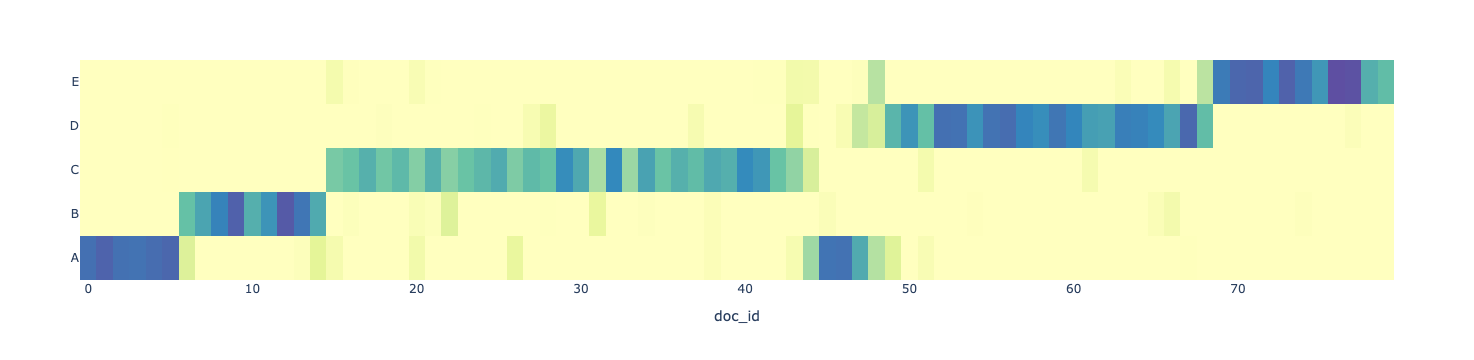

In [479]:
px.imshow(chunk_model.THETA.T.sort_index(ascending=False), 
          color_continuous_scale=px.colors.diverging.Spectral, 
          color_continuous_midpoint=0).update_layout(coloraxis_showscale=False)

## Apply Chunk Model to Chap

In [480]:
chunk_model.apply_model(doc_cols)

### Using Phi

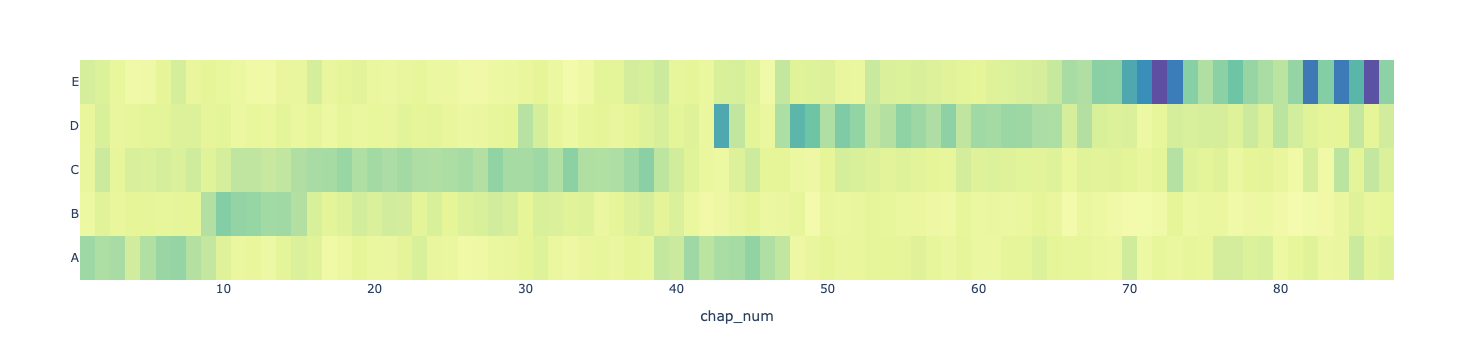

In [481]:
px.imshow(chunk_model.DOC2_TOPIC_PHI.T.sort_index(ascending=False), 
          color_continuous_scale=px.colors.diverging.Spectral, 
          color_continuous_midpoint=0
         ).update_layout(coloraxis_showscale=False)

### Using Theta

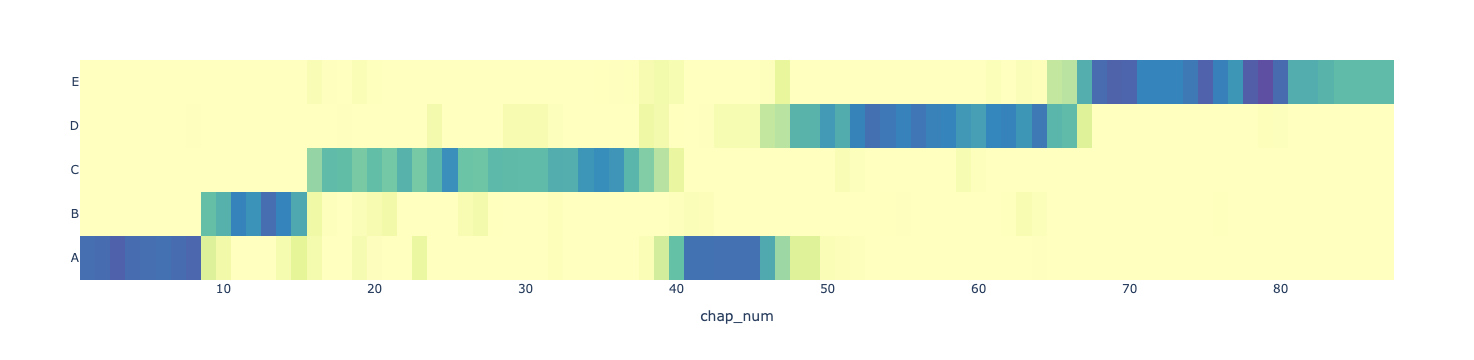

In [482]:
px.imshow(chunk_model.DOC2_TOPIC_THETA.T.sort_index(ascending=False),  
          color_continuous_scale=px.colors.diverging.Spectral, 
          color_continuous_midpoint=0
         ).update_layout(coloraxis_showscale=False)

# Save

In [483]:
# chap_model.export_data()

In [484]:
chunk_model.export_data()

No table THETA_SEQ


# Play

## Altair testing

In [485]:
Q = chunk_model.THETA.stack().to_frame().reset_index()
Q.columns = ['x','y','z']
Q.head()

,x,y,z
0,0,D,1.669564e-14
1,0,C,3.882246e-17
2,0,E,1.124934e-09
3,0,A,3.893424e-01
4,0,B,4.140213e-13


In [486]:
(
    alt.Chart(Q)
    .mark_rect()
    .encode(
        alt.X('x:O').title('chunk').axis(labelAngle=0),
        alt.Y('y:O').title('topic'),
        color = 'z'
    )
    .properties(
        width=1000,
        height=150
    )
)

alt.Chart(...)

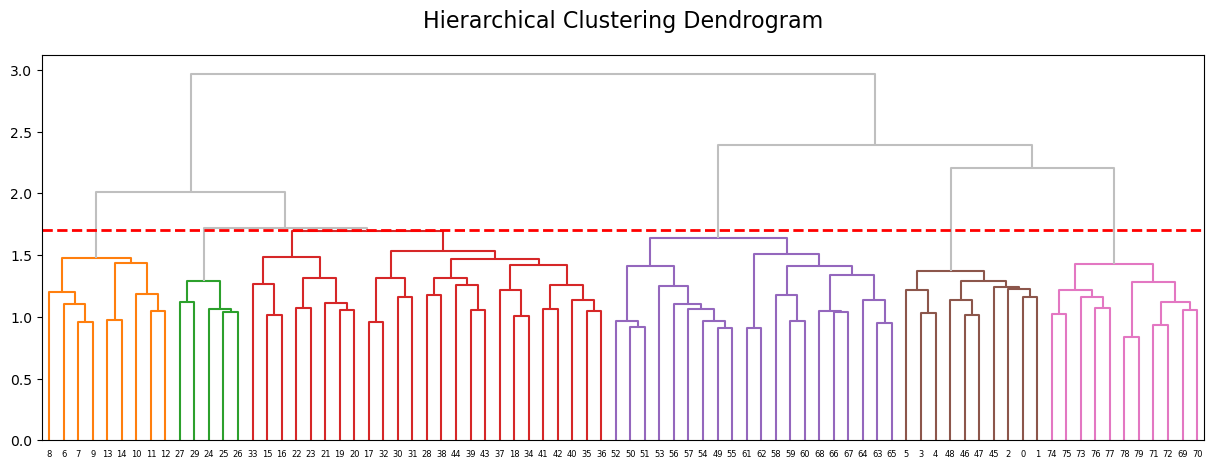

In [487]:
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch

# Define the canvas for plotting
plt.figure(figsize=(15, 5))

# Create a dendrogram
sch.dendrogram(
    chunk_cluster.tfidf_hac.TREE,
    count_sort=True,
    distance_sort=True,
    above_threshold_color='.75',
    color_threshold=1.7
)

# Add features to the plot
plt.title("Hierarchical Clustering Dendrogram", fontsize=16, pad=20)
plt.axhline(y=1.7, color='red', linestyle='--', linewidth=2)
plt.xticks(rotation=0) 

# Show the results
plt.show()